# Example 2 &ndash; Coupled Simulation

This example builds on the acoustic simulation from Example 1, if you haven't done so already, ***please run Example 1 before running this one.***


In [2]:
import xarray as xr
import numpy as np

from frequensolve import *

project = Project.copy(
    src = "scratch/ex_01/project.json", 
    dest = "scratch/ex_02/",
    name = "ex_02",
    pretty_name = "Coupled Simulation"
)

The 'parrallel' dependencies are required to use remote sites, install them with 'poetry install --with parallel'


## Coupled Physics

SeismicSimulation currently supports the following `physics`:

- `acoustic`
- `elastic`
- `coupled`

Attenuation is supported by simply specifying `Qp` and `Qs` (no special distinction is made for visco-acoustic and
viso-elastic physics since attenuation simply introduces a complex-valued wavespeed). For coupled physics, the physics
can specified per-subdomain (layer) via the `physics`; otherwise the physics is indicated by whether or not elastic properties are specified on the subdomain. 

In the following we change Example 1 physics to `coupled` and convert the lower layer to an elastic domain.

surfaces:
 ['top', 'interface', 'bottom']
layers:
 ['layer_1', 'layer_2']


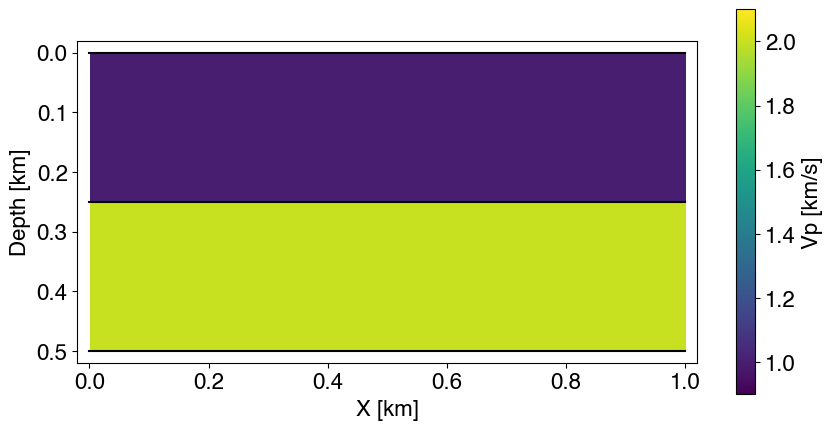

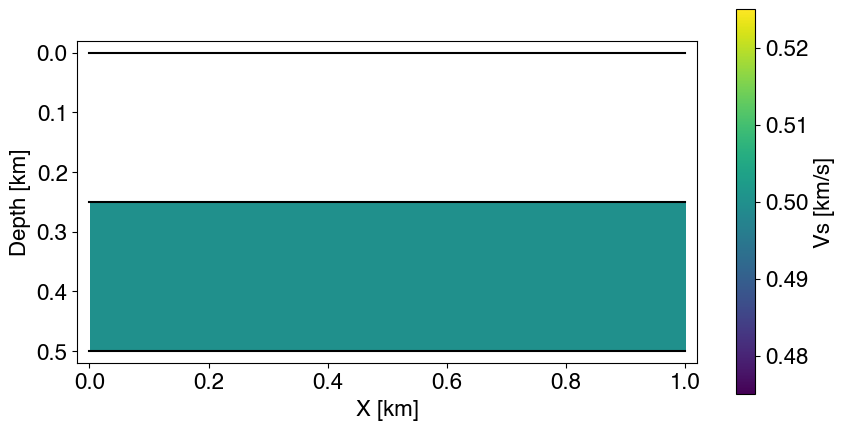

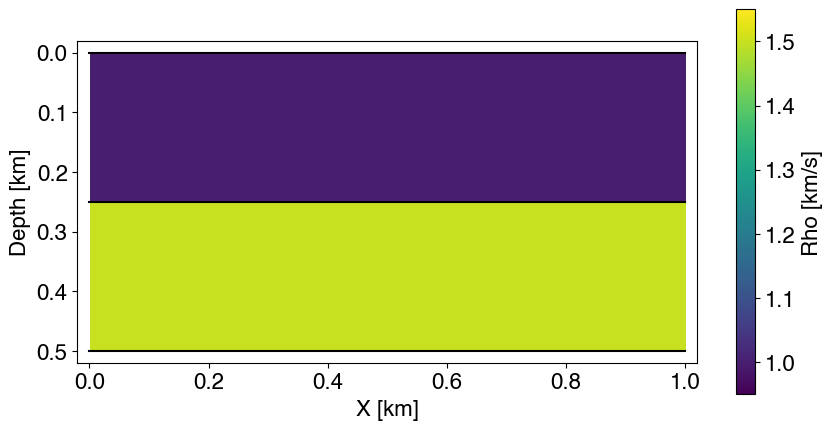

In [3]:
sim = project.simulations["simulation_01"]

# Change simulation physics to "coupled"
sim.physics = "coupled"
model = sim.model

print("surfaces:\n", model.surface_names)
print("layers:\n", model.layer_names)

layer1 = model.layers["layer_1"]
layer1.name = "fluid"
layer1.physics = "acoustic"
layer1.properties = {
    "Vp" : 1.0, 
    "Qp" : 200.0, 
    "Rho": 1.0
}

layer2 = model.layers["layer_2"]
layer2.name = "solid"
layer2.physics = "elastic"
layer2.properties = {
    "Vp" : 2.0, 
    "Qp" : 100.0, 
    "Vs" : 0.5,
    "Qs" : 50.0,
    "Rho": 1.5
}

model.plot("Vp",figsize=(10,5),fontsize=16,aspect="equal")
model.plot("Vs",figsize=(10,5),fontsize=16,aspect="equal")
model.plot("Rho",figsize=(10,5),fontsize=16,aspect="equal")

## Heterogeneity

Heterogeneity can be added via the `perturb` function of both layers and surfaces (`perturb` is a thin wrapper
for the Von Karman stochastic field functions in `frequensolve.utils.stochastic_fields`). 

In the following we first perturb `Vp`, `Vs`, and `Rho` in the solid domain; we then perturb the surface and
the interface between the two domains.

Note that when we perturb the solid domain, the property grid is no longer defined over the whole layer. When
a point lands outside the grid it is projected onto the nearest grid point. This is thus not numerically 
problematic for the simulation, but can be fixed by redefining `grid` to cover a larger domain.

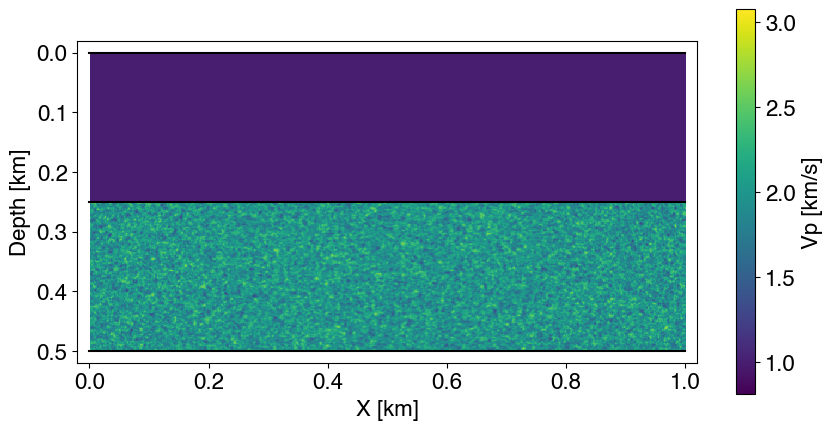

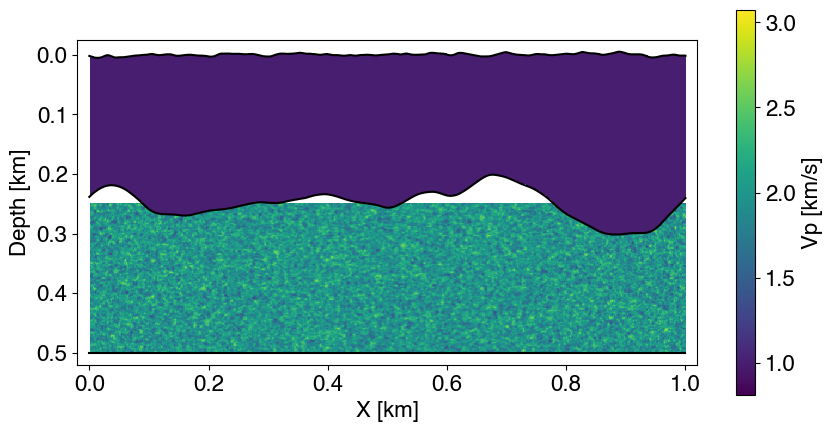

In [4]:
# Define grid for perturbation
grid = xr.DataArray(
    dims = ["x", "z"], 
    coords = {"x": np.linspace(0.0,  1.0, 501),
              "z": np.linspace(0.25, 0.5, 501)}
)       
 
 # Seed is the random-number generator seed, its value doesn't
 # particularly matter but is fixed here for reproducability
layer2.perturb(
    property = ["Vs", "Vp", "Rho"],
    std = 0.1,
    L0 = 0.001,
    nu = 0.5,
    anisotropy = [1.0, 1.0],
    xarr = grid,
    seed = 12
)

model.plot(
    property = "Vp",
    figsize = (10,5),
    fontsize = 16,
    aspect = "equal"
)

# Define grid for perturbation
grid = xr.DataArray(
    dims=["x"], 
    coords={"x": np.linspace(0.0, 1.0, 501)}
)    

# Perturb the top surface
surface = model.surfaces["top"]
surface.perturb(
    std = 0.002,
    L0 = 0.005,
    nu = 1,
    xarr = grid,
    seed = 20
)

# Perturb the middle surface
interface = model.surfaces["interface"]
interface.perturb(
    std = 0.025,
    L0 = 0.05,
    nu = 0.5,
    xarr = grid,
    seed = 15
)

model.plot(
    property = "Vp",
    figsize = (10,5),
    fontsize = 16,
    aspect = "equal"
)

## Coordinate Frames

Various classes in FrequenSolve have a `frame` attribute. This attribute indicates the frame of reference in
which spatial coordinates are defined. To understand this, consider the domain before surfaces were warped
and after. The materials (and other spatial quantities) can be defined in either configuration and then mapped
to the other (the mapping is defined by linearly interpolating the deformation of the surfaces above and below
the layer). Two options are currently supported:

- `physical` (default): Spatial coordinates correspond to the physical domain.
- `reference`: Spatial coordinates are defined in the reference domain (and subsequently mapped to the physical domain).

The reference configuration can be defined by specifying `z_ref` when defining surfaces in a layered model (`z_ref` 
defaults to the average elevation of the surface over the domain). Changing the solid layer frame to `reference` below 
illustrates the difference.

All frames default to `physical` as it separates surface and velocity model definition. Source and receiver locations can 
be specified in either `reference` or `phyiscal` frame; specifying locations in the reference frame is particularly useful 
for positioning at along the surface, seafloor, or any other surface of interest.

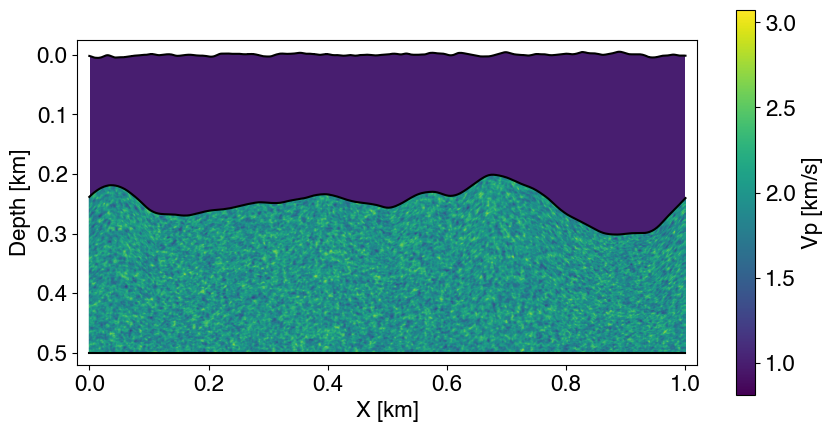

In [5]:
layer2.frame = "reference"
model.plot(
    property = "Vp",
    resolution = [1000,1000],
    figsize = (10,5),
    fontsize = 16,
    aspect = "equal"
)

hydrophones = sim.acquisition.receiver_groups["surface_hydrophones"]
hydrophones.frame = "reference"

source = sim.acquisition.source_group
source.frame = "reference"

In [7]:
project.save()

site = "frontera"

# --- Connect to site ---
if site == "local":
    project.site = LocalSite()
elif site == "frontera":
    project.site = FronteraSite(rel_path = "FrequenSolve/ex_02/")
    project.site.attach_to_existing_job()
    
project.transfer()

fd_job = FrequencyDomainJob(
    name = "fd_job",
    simulation = sim,
    f_list = [20.0]
)
fd_results = project.submit_job(fd_job)

INFO: Starting authentication with host: frontera.tacc.utexas.edu
INFO: Secure connection established with host: frontera.tacc.utexas.edu


Connection test


INFO: SSH client authenticated successfully
INFO: Work directory: /work2/09664/mssujith/frontera/FrequenSolve/ex_02
INFO: FronteraSite initialized with work_dir: /work2/09664/mssujith/frontera/FrequenSolve/ex_02
INFO: Deleting FronteraSite instance and cleaning up resources.
INFO: Attaching to existing job with ID: 6975206


 --- User Jobs ---
 6975206   c201-015     8    R      56:23

Attatched to job:
6975206   c201-015     8    R      56:23


INFO: Pool info - host: c201-015, nodes: 8, tasks: 16, cores: 448, start: 2025-03-08T17:15:27, end: 2025-03-08T19:15:27
INFO: Current status of pool 6975206: running


ssh c201-015
Last login: Sat Mar  8 18:17:27 2025 from 72.182.42.233
------------------------------------------------------------------------------
Welcome to the Frontera Supercomputer
Texas Advanced Computing Center, The University of Texas at Austin
------------------------------------------------------------------------------
** Unauthorized use/access is prohibited. **
If you log on to this computer system, you acknowledge your awareness
of and concurrence with the UT Austin Acceptable Use Policy. The
University will prosecute violators to the full extent of the law.
TACC Usage Policies:
http://www.tacc.utexas.edu/user-services/usage-policies/
______________________________________________________________________________
Welcome to Frontera, *please* read these important system notes:
--> Frontera user documentation is available at:
https://portal.tacc.utexas.edu/user-guides/frontera
cd /work2/09664/mssujith/fssh c201-015
--------------------- Project balances for user mssujith --

INFO: Sweep job completed successfully
